In [1]:
import pandas as pd
from pathlib import Path
from tqdm import tqdm
import numpy as np
# from sklearn.metrics import precision_recall_fscore_support
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Arial"
import seaborn as sns
# from joblib import Parallel, delayed
import re
import os
from itertools import combinations
# from statsmodels.stats.multitest import multipletests


In [2]:
nacc_path = Path('/projectnb/vkolagrp/projects/adrd_foundation_model/results/NACC/test_np_one')

In [3]:
model_map = {
    "Qwen2.5-3B-Instruct": "Q3B",
    # "NACC-3B": "LUNAR-OS-SCe",
    # "NACC-3B-SCE": "LUNAR-OS",
    # "NACC-3B-OS": "LUNAR-SCe",
    "NACC-3B-OS-SCE": "LUNAR",
    "Qwen2.5-7B-Instruct": "Q7B",
}

class_map = {
    "Alzheimer's disease pathology (AD)": 'AD',
    "Frontotemporal Lobar Degeneration with tau pathology or TDP-43 pathology (FTLD)": 'FTLD',
    "Lewy body pathology (LBD)": 'LBD',
    "No listed option is correct": "None"
}

class_order = ['None','AD','LBD','FTLD']

# class_map = {
#     "Alzheimer's disease pathology (AD) and Frontotemporal Lobar Degeneration with tau pathology or TDP-43 pathology (FTLD)": 'AD and FTLD',
#     "Alzheimer's disease pathology (AD) and Lewy body pathology (LBD)": 'AD and LBD',
#     "Alzheimer's disease pathology (AD), Lewy body pathology (LBD) and Frontotemporal Lobar Degeneration with tau pathology or TDP-43 pathology (FTLD)": 'AD, LBD and FTLD',
#     "Lewy body pathology (LBD) and Frontotemporal Lobar Degeneration with tau pathology or TDP-43 pathology (FTLD)": "LBD and FTLD",
#     "No listed option is correct": "None"
# }
# class_order = ['None','AD and LBD','AD and FTLD','LBD and FTLD', 'AD, LBD and FTLD']

In [4]:
def option_string_to_dict(options):
    # The option string is randomized (e.g. NC is not always option A). We need to break down the 
    # options and look at the text (e.g. MCI), not just the letter that identifies them in a particular question
    pattern = r"([A-Z])\. ([^\n]+)"
    matches = re.findall(pattern, options)
    return {key: value for key, value in matches}

def load_answers(dir_path, dataset_name):
    # load all parquet files from the directory, stack them into a pandas datafame
    # this only reads the participant ID, ground trush answer and the prediction. 
    # Reading only those columns is significantly faster (about 100x) than loading the whole dataframe.
    # Loading everything is very slow because there are extremely long strings (model outputs) in some columns

    fpaths = list(dir_path.rglob('*.parquet'))

    dfs = []

    cols_to_read = ['ID','ground_truth','prediction','ground_truth_text','options']#, 'generated_text']

    for fpath in tqdm(fpaths):

        model = fpath.parent.name.split('-',3)[-1] 
        benchmark = fpath.parent.parent.name.split('_',1)[-1].upper()

        df = pd.read_parquet(fpath,columns=cols_to_read)
    
        df = df.assign(model=model, benchmark=benchmark)

        df['correct'] = (df['ground_truth'] == df['prediction']).astype(int)

        df['prediction_text'] = df.apply(lambda row: option_string_to_dict(row['options']).get(row['prediction'],'invalid'),axis=1)

        dfs.append(df)

    df = pd.concat(dfs)
    df['dataset'] = dataset_name

    # make these columns Categorical
    group_cols = ["dataset", "benchmark", "model", "ground_truth_text", 'prediction_text']
    for col in group_cols:
        df[col] = pd.Categorical(df[col])

    # keep only the models we actually care about
    df = df[df['model'].isin(list(model_map.keys()))]

    return df


In [5]:
nacc_res = load_answers(nacc_path,dataset_name='NACC')

  0%|          | 0/8 [00:00<?, ?it/s]

100%|██████████| 8/8 [00:00<00:00,  9.01it/s]


In [6]:
nacc_res.prediction_text.unique()

['Lewy body pathology (LBD)', 'Alzheimer's disease pathology (AD)', 'Frontotemporal Lobar Degeneration with tau pa..., 'No listed option is correct']
Categories (4, object): ['Alzheimer's disease pathology (AD)', 'Frontotemporal Lobar Degeneration with tau pa..., 'Lewy body pathology (LBD)', 'No listed option is correct']

In [7]:
nacc_res["trial"] = nacc_res.index

In [8]:
import numpy as np
import pandas as pd
from joblib import Parallel, delayed
from itertools import combinations
from statsmodels.stats.multitest import multipletests

def _vectorized_metric_calc(y_true, y_pred, label_code, metric):
    """Core vectorized math for both bootstrap and permutation."""
    tp = np.sum((y_pred == label_code) & (y_true == label_code), axis=-1)
    
    if metric == 'precision':
        den = np.sum(y_pred == label_code, axis=-1)
    elif metric == 'recall':
        den = np.sum(y_true == label_code, axis=-1)
    elif metric == 'f1':
        precision_den = np.sum(y_pred == label_code, axis=-1)
        recall_den = np.sum(y_true == label_code, axis=-1)
        precision = np.divide(
            tp, precision_den, out=np.zeros_like(tp, dtype=float), where=precision_den != 0
        )
        recall = np.divide(
            tp, recall_den, out=np.zeros_like(tp, dtype=float), where=recall_den != 0
        )
        with np.errstate(divide='ignore', invalid='ignore'):
            f1 = np.divide(
                2 * precision * recall,
                precision + recall,
                out=np.zeros_like(tp, dtype=float),
                where=(precision + recall) != 0,
            )
        return f1
    else:
        raise ValueError(f"Unknown metric: {metric}")
    return np.divide(tp, den, out=np.zeros_like(tp, dtype=float), where=den != 0)



In [9]:
def _single_bootstrap_task(group_info, y_true_b, y_pred_b, lbl_code, m_type):
    """Worker for individual bootstrap metric tasks to saturate 20+ cores."""
    boot_values = _vectorized_metric_calc(y_true_b, y_pred_b, lbl_code, m_type)
    low, med, high = np.percentile(boot_values, [2.5, 50, 97.5])
    return {
        **group_info, "class_code": lbl_code, "metric": m_type,
        "mean": np.mean(boot_values), "median": med, "low": low, "high": high
    }

def optimized_bootstrap_parallel(df, n_boot=1000, seed=42, n_jobs=-1):
    """
    Bootstrap CIs for precision/recall per (dataset, benchmark, model, class).
    """
    # Keep original text columns for grouping
    df_grouped = df[["ID", "trial", "dataset", "benchmark", "model", "ground_truth_text", "prediction_text"]].copy()
    
    # Build tasks
    groups = list(df_grouped.groupby(["dataset", "benchmark", "model"], observed=True))
    main_rng = np.random.default_rng(seed)
    all_tasks = []
    
    # We'll build a global int_to_label mapping after collecting all groups
    all_int_to_label = {}
    
    print(f"Preparing Bootstrap data for {len(groups)} groups...")
    
    for i, (g_id, group) in enumerate(groups):
        # Sort by ID for consistency
        group = group.sort_values(['ID', "trial"]).reset_index(drop=True)
        
        # Get all unique categories for THIS group
        gt_cats = group["ground_truth_text"].astype("category").cat.categories.tolist()
        pred_cats = group["prediction_text"].astype("category").cat.categories.tolist()
        all_cats = sorted(set(gt_cats + pred_cats))
        
        # Ensure 'invalid' is included
        if "invalid" not in all_cats:
            all_cats.append("invalid")
        
        # Create shared categorical dtype for this group
        cat_dtype = pd.CategoricalDtype(categories=all_cats, ordered=False)
        invalid_code = all_cats.index("invalid")
        
        # Encode with consistent mapping
        y_true = group["ground_truth_text"].astype(cat_dtype).cat.codes.astype(np.int16).to_numpy()
        y_pred = group["prediction_text"].astype(cat_dtype).cat.codes.astype(np.int16).to_numpy()
        
        # Labels to process (exclude invalid)
        labels_to_process = [i for i in range(len(all_cats)) if i != invalid_code]
        
        # Store mapping for this group (we'll merge later)
        group_key = (g_id[0], g_id[1], g_id[2])
        all_int_to_label[group_key] = {i: cat for i, cat in enumerate(all_cats)}
        
        group_seed = int(main_rng.integers(0, 2**32))
        rng = np.random.default_rng(group_seed)
        
        # Generate indices once per group
        indices = rng.integers(0, len(y_true), size=(n_boot, len(y_true)))
        y_true_b = y_true[indices]
        y_pred_b = y_pred[indices]
        
        for lbl_code in labels_to_process:
            for m_type in ['precision', 'recall', 'f1']:
                all_tasks.append((
                    {"dataset": g_id[0], "benchmark": g_id[1], "model": g_id[2]},
                    y_true_b, y_pred_b, lbl_code, m_type
                ))
    
    print(f"Executing Bootstrap on {len(all_tasks)} tasks across {n_jobs} cores...")
    results = Parallel(n_jobs=n_jobs)(delayed(_single_bootstrap_task)(*t) for t in all_tasks)
    
    res_df = pd.DataFrame(results)
    
    # Map class codes back to labels using group-specific mappings
    res_df['class'] = res_df.apply(
        lambda row: all_int_to_label[(row['dataset'], row['benchmark'], row['model'])][row['class_code']],
        axis=1
    )
    
    return res_df.drop(columns=['class_code'])

In [11]:
def get_significance_marker(p_value):
    if isinstance(p_value, str):
        return p_value
    if pd.isna(p_value):
        return ""
    if p_value < 0.0001:
        return "****"
    elif p_value < 0.001:
        return "***"
    elif p_value < 0.01:
        return "**"
    elif p_value < 0.05:
        return "*"
    elif p_value <= 1.0:
        return "ns"
    else:
        return str(p_value)

def _permutation_worker(task, n_perms, seed):
    """Worker for individual permutation tasks."""
    rng = np.random.default_rng(seed)
    id_array = task["id_array"]
    yt, yp1, yp2, lbl_code, m_type = task['yt'], task['yp1'], task['yp2'], task['class_code'], task['metric']
    
    obs_diff = _vectorized_metric_calc(yt, yp1, lbl_code, m_type) - _vectorized_metric_calc(yt, yp2, lbl_code, m_type)
    
    # Vectorized swap across all permutations
    unique_ids, id_indices = np.unique(id_array, return_inverse=True)
    n_ids = len(unique_ids)
    
    # Generate ALL permutations at once: shape (n_perms, n_ids)
    swap_ids = rng.integers(0, 2, size=(n_perms, n_ids), dtype=bool)
    
    # Map ID-level swaps to trial-level: shape (n_perms, n_samples)
    swap = swap_ids[:, id_indices] 
    
    # Now we can vectorize again
    p1 = np.where(swap[:, None], yp2, yp1)  # Shape: (n_perms, n_samples)
    p2 = np.where(swap[:, None], yp1, yp2)
    
    null1 = _vectorized_metric_calc(yt, p1, lbl_code, m_type)
    null2 = _vectorized_metric_calc(yt, p2, lbl_code, m_type)
    
    p_val = np.mean(np.abs(null1 - null2) >= np.abs(obs_diff))
    return {k: v for k, v in task.items() if k not in ['yt', 'yp1', 'yp2']} | {'p_value': p_val, 'observed_diff': obs_diff}

def compute_pairwise_comparisons_optimized(df, n_permutations=1000, seed=42, n_jobs=-1):
    """
    Permutation tests on precision/recall between model pairs within each (dataset, benchmark).
    Applies BH correction.
    """
    # Keep original text columns for grouping
    df_grouped = df[["ID", "trial", "dataset", "benchmark", "model", "ground_truth_text", "prediction_text"]].copy()
    
    # Store mappings for each dataset/benchmark
    all_int_to_label = {}
    
    tasks = []
    for (ds, bench), group in df_grouped.groupby(["dataset", "benchmark"], observed=True):
        # Get all unique categories for THIS dataset/benchmark
        gt_cats = group["ground_truth_text"].astype("category").cat.categories.tolist()
        pred_cats = group["prediction_text"].astype("category").cat.categories.tolist()
        all_cats = sorted(set(gt_cats + pred_cats))
        
        # Ensure 'invalid' is included
        if "invalid" not in all_cats:
            all_cats.append("invalid")
        
        # Create shared categorical dtype for this dataset/benchmark
        cat_dtype = pd.CategoricalDtype(categories=all_cats, ordered=False)
        invalid_code = all_cats.index("invalid")
        
        # Labels to process (exclude invalid)
        labels_to_process = [i for i in range(len(all_cats)) if i != invalid_code]
        
        # Store mapping
        all_int_to_label[(ds, bench)] = {i: cat for i, cat in enumerate(all_cats)}
        
        # Encode with consistent mapping
        group_int = pd.DataFrame({
            "ID": group["ID"],
            "trial": group["trial"],
            "model": group["model"],
            "y_true": group["ground_truth_text"].astype(cat_dtype).cat.codes.astype(np.int16),
            "y_pred": group["prediction_text"].astype(cat_dtype).cat.codes.astype(np.int16),
        })
        
        models = sorted(group_int["model"].unique())
        
        for m1, m2 in combinations(models, 2):
            d1 = group_int[group_int["model"] == m1].sort_values(['ID', "trial"]).reset_index(drop=True)
            d2 = group_int[group_int["model"] == m2].sort_values(['ID', "trial"]).reset_index(drop=True)
            
            if len(d1) != len(d2):
                continue  # needs paired alignment
            
            yt = d1["y_true"].to_numpy()
            yp1 = d1["y_pred"].to_numpy()
            yp2 = d2["y_pred"].to_numpy()
            id_array = d1["ID"].to_numpy()
            
            for lbl_code in labels_to_process:
                for m_type in ['precision', 'recall', 'f1']:
                    tasks.append({
                        'dataset': ds,
                        'benchmark': bench,
                        'model1': m1,
                        'model2': m2,
                        'class_code': lbl_code,
                        'metric': m_type,
                        'yt': yt,
                        'yp1': yp1,
                        'yp2': yp2,
                        "id_array": id_array,  # NEW
                    })
    
    print(f"Executing Permutation Tests on {len(tasks)} tasks...")
    seeds = np.random.default_rng(seed).integers(0, 2**32, size=len(tasks))
    results = Parallel(n_jobs=n_jobs)(
        delayed(_permutation_worker)(tasks[i], n_permutations, int(seeds[i]))
        for i in range(len(tasks))
    )
    
    res_df = pd.DataFrame(results)
    
    # Map class codes back to labels using dataset/benchmark-specific mappings
    res_df['class'] = res_df.apply(
        lambda row: all_int_to_label[(row['dataset'], row['benchmark'])][row['class_code']],
        axis=1
    )
    
    # if len(res_df) > 0:
    #     _, res_df['p_value_bh'], _, _ = multipletests(res_df['p_value'], method='fdr_bh')
    # else:
    #     res_df['p_value_bh'] = []
        
    res_df["p_value_bh"] = np.nan
    for keys, sub_idx in res_df.groupby(["dataset", "class", "metric"]).groups.items():
        print(keys, len(sub_idx))
        p = res_df.loc[sub_idx, "p_value"].to_numpy()
        _, p_bh, _, _ = multipletests(p, method="fdr_bh")
        res_df.loc[sub_idx, "p_value_bh"] = p_bh
        
    res_df["Significant_bh"] = res_df["p_value_bh"] < 0.05
    res_df['marker'] = res_df['p_value_bh'].apply(get_significance_marker)
    
    return res_df.drop(columns=['class_code'])

In [12]:
# Step 1: Compute bootstrap CIs with samples
all_metrics = optimized_bootstrap_parallel(
    nacc_res, n_boot=1000, seed=42, n_jobs=20
)

Preparing Bootstrap data for 3 groups...
Executing Bootstrap on 36 tasks across 20 cores...


In [16]:
all_metrics[all_metrics['metric'].isin(['f1'])].sort_values(['dataset','model','metric', 'class'])

,dataset,benchmark,model,metric,mean,median,low,high,class
2,NACC,NP_ONE,NACC-3B-OS-SCE,f1,0.668947,0.669069,0.641932,0.694635,Alzheimer's disease pathology (AD)
5,NACC,NP_ONE,NACC-3B-OS-SCE,f1,0.592349,0.592322,0.559496,0.626136,Frontotemporal Lobar Degeneration with tau pat...
8,NACC,NP_ONE,NACC-3B-OS-SCE,f1,0.399213,0.399077,0.336585,0.456148,Lewy body pathology (LBD)
11,NACC,NP_ONE,NACC-3B-OS-SCE,f1,0.285943,0.286198,0.238087,0.331672,No listed option is correct
14,NACC,NP_ONE,Qwen2.5-3B-Instruct,f1,0.658052,0.658298,0.631950,0.681864,Alzheimer's disease pathology (AD)
17,NACC,NP_ONE,Qwen2.5-3B-Instruct,f1,0.552486,0.552618,0.514158,0.589903,Frontotemporal Lobar Degeneration with tau pat...
20,NACC,NP_ONE,Qwen2.5-3B-Instruct,f1,0.218810,0.217605,0.157698,0.283080,Lewy body pathology (LBD)
23,NACC,NP_ONE,Qwen2.5-3B-Instruct,f1,0.109069,0.108974,0.071575,0.146943,No listed option is correct
26,NACC,NP_ONE,Qwen2.5-7B-Instruct,f1,0.723527,0.723293,0.701378,0.745621,Alzheimer's disease pathology (AD)
29,NACC,NP_ONE,Qwen2.5-7B-Instruct,f1,0.568124,0.568819,0.527666,0.609238,Frontotemporal Lobar Degeneration with tau pat...


In [17]:
all_metrics[all_metrics['metric'].isin(['precision'])].sort_values(['dataset','model','metric', 'class'])

,dataset,benchmark,model,metric,mean,median,low,high,class
0,NACC,NP_ONE,NACC-3B-OS-SCE,precision,0.760870,0.761080,0.730862,0.791098,Alzheimer's disease pathology (AD)
3,NACC,NP_ONE,NACC-3B-OS-SCE,precision,0.543938,0.544070,0.504286,0.583634,Frontotemporal Lobar Degeneration with tau pat...
6,NACC,NP_ONE,NACC-3B-OS-SCE,precision,0.297908,0.297800,0.244896,0.350216,Lewy body pathology (LBD)
9,NACC,NP_ONE,NACC-3B-OS-SCE,precision,0.313678,0.313800,0.261178,0.367134,No listed option is correct
12,NACC,NP_ONE,Qwen2.5-3B-Instruct,precision,0.607116,0.607274,0.576004,0.636541,Alzheimer's disease pathology (AD)
15,NACC,NP_ONE,Qwen2.5-3B-Instruct,precision,0.580613,0.579409,0.535304,0.627197,Frontotemporal Lobar Degeneration with tau pat...
18,NACC,NP_ONE,Qwen2.5-3B-Instruct,precision,0.200560,0.197995,0.141933,0.267389,Lewy body pathology (LBD)
21,NACC,NP_ONE,Qwen2.5-3B-Instruct,precision,0.161056,0.160539,0.105625,0.217120,No listed option is correct
24,NACC,NP_ONE,Qwen2.5-7B-Instruct,precision,0.652915,0.652742,0.625312,0.680930,Alzheimer's disease pathology (AD)
27,NACC,NP_ONE,Qwen2.5-7B-Instruct,precision,0.755210,0.756098,0.704366,0.803421,Frontotemporal Lobar Degeneration with tau pat...


In [18]:
all_metrics[all_metrics['metric'].isin(['recall'])].sort_values(['dataset','model','metric', 'class'])

,dataset,benchmark,model,metric,mean,median,low,high,class
1,NACC,NP_ONE,NACC-3B-OS-SCE,recall,0.597059,0.597458,0.563991,0.628063,Alzheimer's disease pathology (AD)
4,NACC,NP_ONE,NACC-3B-OS-SCE,recall,0.650779,0.650544,0.608605,0.691359,Frontotemporal Lobar Degeneration with tau pat...
7,NACC,NP_ONE,NACC-3B-OS-SCE,recall,0.607460,0.606483,0.532725,0.688326,Lewy body pathology (LBD)
10,NACC,NP_ONE,NACC-3B-OS-SCE,recall,0.263347,0.263483,0.216605,0.310979,No listed option is correct
13,NACC,NP_ONE,Qwen2.5-3B-Instruct,recall,0.718600,0.718817,0.689193,0.746419,Alzheimer's disease pathology (AD)
16,NACC,NP_ONE,Qwen2.5-3B-Instruct,recall,0.527432,0.528078,0.482457,0.570595,Frontotemporal Lobar Degeneration with tau pat...
19,NACC,NP_ONE,Qwen2.5-3B-Instruct,recall,0.241837,0.240741,0.172804,0.313972,Lewy body pathology (LBD)
22,NACC,NP_ONE,Qwen2.5-3B-Instruct,recall,0.082677,0.082491,0.053870,0.113278,No listed option is correct
25,NACC,NP_ONE,Qwen2.5-7B-Instruct,recall,0.811532,0.811465,0.785179,0.836690,Alzheimer's disease pathology (AD)
28,NACC,NP_ONE,Qwen2.5-7B-Instruct,recall,0.455708,0.455588,0.413356,0.497891,Frontotemporal Lobar Degeneration with tau pat...


In [19]:
# Step 2: Compute pairwise comparisons using permutation tests on original data
pairwise_comparisons = compute_pairwise_comparisons_optimized(
    nacc_res, n_permutations=10000, seed=42, n_jobs=1
)

Executing Permutation Tests on 36 tasks...
('NACC', "Alzheimer's disease pathology (AD)", 'f1') 3
('NACC', "Alzheimer's disease pathology (AD)", 'precision') 3
('NACC', "Alzheimer's disease pathology (AD)", 'recall') 3
('NACC', 'Frontotemporal Lobar Degeneration with tau pathology or TDP-43 pathology (FTLD)', 'f1') 3
('NACC', 'Frontotemporal Lobar Degeneration with tau pathology or TDP-43 pathology (FTLD)', 'precision') 3
('NACC', 'Frontotemporal Lobar Degeneration with tau pathology or TDP-43 pathology (FTLD)', 'recall') 3
('NACC', 'Lewy body pathology (LBD)', 'f1') 3
('NACC', 'Lewy body pathology (LBD)', 'precision') 3
('NACC', 'Lewy body pathology (LBD)', 'recall') 3
('NACC', 'No listed option is correct', 'f1') 3
('NACC', 'No listed option is correct', 'precision') 3
('NACC', 'No listed option is correct', 'recall') 3


In [20]:
pairwise_comparisons[pairwise_comparisons['metric'].isin(['f1'])]

,dataset,benchmark,model1,model2,metric,id_array,p_value,observed_diff,class,p_value_bh,Significant_bh,marker
2,NACC,NP_ONE,NACC-3B-OS-SCE,Qwen2.5-3B-Instruct,f1,"[NACC005244, NACC005244, NACC005244, NACC00524...",0.5812,0.011468,Alzheimer's disease pathology (AD),0.58120,False,ns
5,NACC,NP_ONE,NACC-3B-OS-SCE,Qwen2.5-3B-Instruct,f1,"[NACC005244, NACC005244, NACC005244, NACC00524...",0.1867,0.039066,Frontotemporal Lobar Degeneration with tau pat...,0.51190,False,ns
8,NACC,NP_ONE,NACC-3B-OS-SCE,Qwen2.5-3B-Instruct,f1,"[NACC005244, NACC005244, NACC005244, NACC00524...",0.0059,0.180343,Lewy body pathology (LBD),0.01770,True,*
11,NACC,NP_ONE,NACC-3B-OS-SCE,Qwen2.5-3B-Instruct,f1,"[NACC005244, NACC005244, NACC005244, NACC00524...",0.0013,0.177687,No listed option is correct,0.00195,True,**
14,NACC,NP_ONE,NACC-3B-OS-SCE,Qwen2.5-7B-Instruct,f1,"[NACC005244, NACC005244, NACC005244, NACC00524...",0.0226,-0.054330,Alzheimer's disease pathology (AD),0.03390,True,*
17,NACC,NP_ONE,NACC-3B-OS-SCE,Qwen2.5-7B-Instruct,f1,"[NACC005244, NACC005244, NACC005244, NACC00524...",0.5119,0.023947,Frontotemporal Lobar Degeneration with tau pat...,0.51190,False,ns
20,NACC,NP_ONE,NACC-3B-OS-SCE,Qwen2.5-7B-Instruct,f1,"[NACC005244, NACC005244, NACC005244, NACC00524...",0.0739,0.077311,Lewy body pathology (LBD),0.08660,False,ns
23,NACC,NP_ONE,NACC-3B-OS-SCE,Qwen2.5-7B-Instruct,f1,"[NACC005244, NACC005244, NACC005244, NACC00524...",0.8985,-0.007176,No listed option is correct,0.89850,False,ns
26,NACC,NP_ONE,Qwen2.5-3B-Instruct,Qwen2.5-7B-Instruct,f1,"[NACC005244, NACC005244, NACC005244, NACC00524...",0.0000,-0.065798,Alzheimer's disease pathology (AD),0.00000,True,****
29,NACC,NP_ONE,Qwen2.5-3B-Instruct,Qwen2.5-7B-Instruct,f1,"[NACC005244, NACC005244, NACC005244, NACC00524...",0.4620,-0.015119,Frontotemporal Lobar Degeneration with tau pat...,0.51190,False,ns


In [21]:
pairwise_comparisons[pairwise_comparisons['metric'].isin(['precision'])]

,dataset,benchmark,model1,model2,metric,id_array,p_value,observed_diff,class,p_value_bh,Significant_bh,marker
0,NACC,NP_ONE,NACC-3B-OS-SCE,Qwen2.5-3B-Instruct,precision,"[NACC005244, NACC005244, NACC005244, NACC00524...",0.0000,0.153740,Alzheimer's disease pathology (AD),0.0000,True,****
3,NACC,NP_ONE,NACC-3B-OS-SCE,Qwen2.5-3B-Instruct,precision,"[NACC005244, NACC005244, NACC005244, NACC00524...",0.2478,-0.037109,Frontotemporal Lobar Degeneration with tau pat...,0.2478,False,ns
6,NACC,NP_ONE,NACC-3B-OS-SCE,Qwen2.5-3B-Instruct,precision,"[NACC005244, NACC005244, NACC005244, NACC00524...",0.0597,0.097297,Lewy body pathology (LBD),0.1791,False,ns
9,NACC,NP_ONE,NACC-3B-OS-SCE,Qwen2.5-3B-Instruct,precision,"[NACC005244, NACC005244, NACC005244, NACC00524...",0.0166,0.153900,No listed option is correct,0.0249,True,*
12,NACC,NP_ONE,NACC-3B-OS-SCE,Qwen2.5-7B-Instruct,precision,"[NACC005244, NACC005244, NACC005244, NACC00524...",0.0000,0.107747,Alzheimer's disease pathology (AD),0.0000,True,****
15,NACC,NP_ONE,NACC-3B-OS-SCE,Qwen2.5-7B-Instruct,precision,"[NACC005244, NACC005244, NACC005244, NACC00524...",0.0000,-0.210578,Frontotemporal Lobar Degeneration with tau pat...,0.0000,True,****
18,NACC,NP_ONE,NACC-3B-OS-SCE,Qwen2.5-7B-Instruct,precision,"[NACC005244, NACC005244, NACC005244, NACC00524...",0.1784,0.046332,Lewy body pathology (LBD),0.2676,False,ns
21,NACC,NP_ONE,NACC-3B-OS-SCE,Qwen2.5-7B-Instruct,precision,"[NACC005244, NACC005244, NACC005244, NACC00524...",0.1003,-0.097035,No listed option is correct,0.1003,False,ns
24,NACC,NP_ONE,Qwen2.5-3B-Instruct,Qwen2.5-7B-Instruct,precision,"[NACC005244, NACC005244, NACC005244, NACC00524...",0.0008,-0.045993,Alzheimer's disease pathology (AD),0.0008,True,***
27,NACC,NP_ONE,Qwen2.5-3B-Instruct,Qwen2.5-7B-Instruct,precision,"[NACC005244, NACC005244, NACC005244, NACC00524...",0.0000,-0.173469,Frontotemporal Lobar Degeneration with tau pat...,0.0000,True,****


In [22]:
pairwise_comparisons[pairwise_comparisons['metric'].isin(['recall'])]

,dataset,benchmark,model1,model2,metric,id_array,p_value,observed_diff,class,p_value_bh,Significant_bh,marker
1,NACC,NP_ONE,NACC-3B-OS-SCE,Qwen2.5-3B-Instruct,recall,"[NACC005244, NACC005244, NACC005244, NACC00524...",0.0000,-0.120652,Alzheimer's disease pathology (AD),0.00000,True,****
4,NACC,NP_ONE,NACC-3B-OS-SCE,Qwen2.5-3B-Instruct,recall,"[NACC005244, NACC005244, NACC005244, NACC00524...",0.0006,0.122000,Frontotemporal Lobar Degeneration with tau pat...,0.00060,True,***
7,NACC,NP_ONE,NACC-3B-OS-SCE,Qwen2.5-3B-Instruct,recall,"[NACC005244, NACC005244, NACC005244, NACC00524...",0.0001,0.365517,Lewy body pathology (LBD),0.00030,True,***
10,NACC,NP_ONE,NACC-3B-OS-SCE,Qwen2.5-3B-Instruct,recall,"[NACC005244, NACC005244, NACC005244, NACC00524...",0.0003,0.180952,No listed option is correct,0.00045,True,***
13,NACC,NP_ONE,NACC-3B-OS-SCE,Qwen2.5-7B-Instruct,recall,"[NACC005244, NACC005244, NACC005244, NACC00524...",0.0000,-0.214130,Alzheimer's disease pathology (AD),0.00000,True,****
16,NACC,NP_ONE,NACC-3B-OS-SCE,Qwen2.5-7B-Instruct,recall,"[NACC005244, NACC005244, NACC005244, NACC00524...",0.0000,0.194000,Frontotemporal Lobar Degeneration with tau pat...,0.00000,True,****
19,NACC,NP_ONE,NACC-3B-OS-SCE,Qwen2.5-7B-Instruct,recall,"[NACC005244, NACC005244, NACC005244, NACC00524...",0.0231,0.158621,Lewy body pathology (LBD),0.02310,True,*
22,NACC,NP_ONE,NACC-3B-OS-SCE,Qwen2.5-7B-Instruct,recall,"[NACC005244, NACC005244, NACC005244, NACC00524...",0.5208,0.034921,No listed option is correct,0.52080,False,ns
25,NACC,NP_ONE,Qwen2.5-3B-Instruct,Qwen2.5-7B-Instruct,recall,"[NACC005244, NACC005244, NACC005244, NACC00524...",0.0000,-0.093478,Alzheimer's disease pathology (AD),0.00000,True,****
28,NACC,NP_ONE,Qwen2.5-3B-Instruct,Qwen2.5-7B-Instruct,recall,"[NACC005244, NACC005244, NACC005244, NACC00524...",0.0002,0.072000,Frontotemporal Lobar Degeneration with tau pat...,0.00030,True,***


In [15]:
pairwise_comparisons['class'].unique()

array(["Alzheimer's disease pathology (AD)",
       'Frontotemporal Lobar Degeneration with tau pathology or TDP-43 pathology (FTLD)',
       'Lewy body pathology (LBD)', 'No listed option is correct'],
      dtype=object)

# Latex

In [16]:
def generate_latex_table(all_metric, model_map, class_map):
    df = all_metric.copy()
    
    # 1. Apply Mappings
    df['model'] = df['model'].map(model_map).fillna(df['model'])
    df['class'] = df['class'].map(class_map).fillna(df['class'])

    # 2. Pivot to get metrics as columns for F1 calculation
    stats = df.pivot_table(
        index=['class', 'model'],
        columns='metric',
        values=['median', 'low', 'high']
    ).reset_index()

    # Flatten multi-index columns: e.g., ('median', 'precision') -> 'precision_median'
    stats.columns = [f"{col[1]}_{col[0]}" if col[1] else col[0] for col in stats.columns]

    # 3. Calculate F1-score for Median and CI
    # for stat in ['median', 'low', 'high']:
    #     p = stats[f'precision_{stat}']
    #     r = stats[f'recall_{stat}']
    #     # Use np.where to handle division by zero safely
    #     stats[f'f1-score_{stat}'] = np.where((p + r) > 0, 2 * (p * r) / (p + r), 0)

    # 4. Define Categorical Sort Order
    model_order = list(model_map.values())
    
    stats['class'] = pd.Categorical(stats['class'], categories=class_order, ordered=True)
    stats['model'] = pd.Categorical(stats['model'], categories=model_order, ordered=True)
    
    # Sort and reset index so loop index 'i' matches the dataframe index
    stats = stats.sort_values(by=['class', 'model']).reset_index(drop=True)

    # 5. Identify the best performing model (highest median) for each metric per group
    metrics = ['precision', 'recall', 'f1']
    # best_lookup = set()
    
    # for m in metrics:
    #     # Pass observed=False to satisfy the future pandas requirement
    #     idx = stats.groupby(['class'], observed=False)[f'{m}_median'].idxmax()
    #     for i in idx:
    #         # Check for NaN to handle groups that might be empty after categorical mapping
    #         if pd.notna(i):
    #             best_lookup.add((i, m))
                
    best_lookup = set()
    second_best_lookup = set()

    for m in metrics:
        col = f"{m}_median"

        # Rank within each (dataset, class), highest value = rank 1
        ranks = stats.groupby(
            ["class"], observed=False
        )[col].rank(method="first", ascending=False)

        # Best (rank == 1)
        best_idx = stats.index[(ranks == 1) & stats[col].notna()]
        for i in best_idx:
            best_lookup.add((i, m))

        # Second best (rank == 2)
        second_idx = stats.index[(ranks == 2) & stats[col].notna()]
        for i in second_idx:
            second_best_lookup.add((i, m))

    # 6. Build LaTeX manually
    headers = ['Class', 'Model', 'Precision', 'Recall', 'F1-score']
    latex_lines = [
        "\\begin{table}[ht]",
        "\\centering",
        "\\small",
        "\\begin{tabular}{lllccc}",
        "\\hline",
        " & ".join(headers) + " \\\\",
        "\\hline"
    ]

    prev_ds, prev_cl = None, None

    for i, row in stats.iterrows():
        # Visual grouping: Add midrule when Class changes
        if prev_cl is not None and row['class'] != prev_cl:
            latex_lines.append("\\hline")
            
        # ds_disp = row['dataset'] if row['dataset'] != prev_ds else ""
        cl_disp = row['class'] if row['class'] != prev_cl else ""
        
        # Format each metric column
        formatted_metrics = []
        for m in metrics:
            val_str = f"{row[f'{m}_median']:.3f} [{row[f'{m}_low']:.3f}, {row[f'{m}_high']:.3f}]"
            if (i, m) in best_lookup:
                val_str = f"\\textbf{{{val_str}}}"
            if (i, m) in second_best_lookup:
                val_str = f"\\underline{{{val_str}}}"
            formatted_metrics.append(val_str)
        
        row_str = f"{cl_disp} & {row['model']} & " + " & ".join(formatted_metrics) + " \\\\"
        latex_lines.append(row_str)
        
        prev_cl = row['class']

    latex_lines.extend(["\\hline", "\\end{tabular}", "\\end{table}"])
    return "\n".join(latex_lines)

In [17]:
latex_output = generate_latex_table(all_metrics, model_map=model_map, class_map=class_map)
print(latex_output)

\begin{table}[ht]
\centering
\small
\begin{tabular}{lllccc}
\hline
Class & Model & Precision & Recall & F1-score \\
\hline
None & Q3B & 0.161 [0.106, 0.217] & 0.082 [0.054, 0.113] & 0.109 [0.072, 0.147] \\
 & LUNAR & \underline{0.314 [0.261, 0.367]} & \textbf{0.263 [0.217, 0.311]} & \underline{0.286 [0.238, 0.332]} \\
 & Q7B & \textbf{0.413 [0.341, 0.485]} & \underline{0.231 [0.186, 0.274]} & \textbf{0.297 [0.245, 0.347]} \\
\hline
AD & Q3B & 0.607 [0.576, 0.637] & \underline{0.719 [0.689, 0.746]} & 0.658 [0.632, 0.682] \\
 & LUNAR & \textbf{0.761 [0.731, 0.791]} & 0.597 [0.564, 0.628] & \underline{0.669 [0.642, 0.695]} \\
 & Q7B & \underline{0.653 [0.625, 0.681]} & \textbf{0.811 [0.785, 0.837]} & \textbf{0.723 [0.701, 0.746]} \\
\hline
LBD & Q3B & 0.198 [0.142, 0.267] & 0.241 [0.173, 0.314] & 0.218 [0.158, 0.283] \\
 & LUNAR & \textbf{0.298 [0.245, 0.350]} & \textbf{0.606 [0.533, 0.688]} & \textbf{0.399 [0.337, 0.456]} \\
 & Q7B & \underline{0.249 [0.199, 0.308]} & \underline{0.445 [0

In [23]:
def get_significance_marker(p_value):
    if isinstance(p_value, str):
        return p_value
    if pd.isna(p_value):
        return ""
    if p_value < 0.0001:
        return "****"
    elif p_value < 0.001:
        return "***"
    elif p_value < 0.01:
        return "**"
    elif p_value < 0.05:
        return "*"
    elif p_value <= 1.0:
        return "ns"
    else:
        return str(p_value)

In [24]:

metric_names = {'precision': 'Precision', 'recall': 'Recall', 'f1': "F1"}
markers = {"Q3B": "s", "LUNAR": "o", "Q7B": "D"}

In [25]:
def plot_classwise_with_pvalues(all_metrics, pairwise_pvalues, 
                                  model_map, class_map, figsize, fontsize,
                                  filename="figure4",
                                  show_all_comparisons=False,
                                  p_threshold=0.05,
                                  metrics=("precision", "recall")):
    """
    Plot classwise precision and recall with p-value annotations.
    
    Parameters
    ----------
    all_metrics : pd.DataFrame
        Results with columns: dataset, model, class, metric, median, low, high
    pairwise_pvalues : pd.DataFrame
        P-values with columns: dataset, class, metric, model1, model2, p_value
    model_map : dict
        Mapping from full model names to abbreviations
    class_map : dict
        Mapping from full class names to abbreviations
    output_dir : str
        Directory to save the figure
    show_all_comparisons : bool
        If True, show all pairwise comparisons. If False, only show comparisons
        involving the first model (typically baseline)
    p_threshold : float
        Only show annotations for p-values below this threshold
    """
    
    # Apply mappings
    models = list(model_map.values())
    metric_names = {'precision': 'Precision', 'recall': 'Recall', 'f1': "F1"}
    all_metrics = all_metrics.copy()
    all_metrics["model_abbrev"] = all_metrics["model"].map(model_map)
    all_metrics["class_abbrev"] = all_metrics["class"].map(class_map).fillna(all_metrics["class"])
    
    # Apply mappings to pairwise_pvalues
    pvalues = pairwise_pvalues.copy()

    # Map abbreviated names to full names for matching
    pvalues["model1_abbrev"] = pvalues["model1"].apply(
        lambda x: model_map.get(x, x)
    )
    pvalues["model2_abbrev"] = pvalues["model2"].apply(
        lambda x: model_map.get(x, x)
    )
    pvalues["class_abbrev"] = pvalues["class"].map(class_map).fillna(pvalues["class"])
    
    # Filter for precision and recall only
    df = all_metrics[all_metrics['metric'].isin(metrics)].copy()
    
    # Get unique values
    datasets = sorted(df["dataset"].unique())
    
    # Define colors for models
    palette = dict(zip(models, sns.color_palette("colorblind", n_colors=len(models))))
    
    # Create figure: rows = metrics, columns = datasets
    # metrics = ['precision', 'recall']
    
    # Ensure axes is 2D even with one dataset
    
    # Fixed orders
    # class_order = ['None','AD','LBD','FTLD']
    # dataset_order = ["NACC", "ADNI", "BrainLat", "NIFD", "PPMI"]
    dataset_order = ["NACC"]
    
    # Override datasets list
    datasets = [d for d in dataset_order if d in df["dataset"].unique()]
    
    n_datasets = len(datasets)
    n_metrics = len(metrics)
    n_models = len(models)
    
    bar_width = 0.8 / n_models
    
    fig, axes = plt.subplots(
        n_metrics, n_datasets,
        figsize=figsize,
        squeeze=False,   # always 2D array
    )
    
    for row_idx, metric in enumerate(metrics):
        for col_idx, dataset in enumerate(datasets):
            ax = axes[row_idx, col_idx]

            present = df[df['dataset'] == dataset]['class_abbrev'].unique()
            dataset_classes = [c for c in class_order if c in present]
            n_classes = len(dataset_classes)

            df_subset = df[(df['dataset'] == dataset) & (df['metric'] == metric)]
            print(len(df_subset))
            bar_info = {model: {'x': [], 'height': []} for model in models}

            for i, model in enumerate(models):
                df_model = df_subset[df_subset['model_abbrev'] == model]

                values, errors_low, errors_high = [], [], []
                for cls in dataset_classes:
                    cls_data = df_model[df_model['class_abbrev'] == cls]
                    if len(cls_data) > 0:
                        values.append(cls_data['median'].values[0])
                        errors_low.append(cls_data['median'].values[0] - cls_data['low'].values[0])
                        errors_high.append(cls_data['high'].values[0] - cls_data['median'].values[0])
                    else:
                        values.append(0)
                        errors_low.append(0)
                        errors_high.append(0)

                x_pos = np.arange(n_classes) + i * bar_width - (n_models - 1) * bar_width / 2
                bar_info[model]['x'] = x_pos
                bar_info[model]['height'] = np.array(values) + np.array(errors_high)

                # Only label in top-right panel
                label = model if (row_idx == 0 and col_idx == n_datasets - 1) else ""
                bars = ax.bar(
                    x_pos, values, bar_width,
                    label=label,
                    color=palette[model], alpha=0.8,
                    yerr=[errors_low, errors_high],
                    capsize=2, error_kw={'linewidth': 0.6, 'elinewidth': 0.6, 'capthick':0.6}
                )

                for bar, val, err_high in zip(bars, values, errors_high):
                    if val > 0:
                        ax.text(
                            bar.get_x() + bar.get_width() / 2,
                            val + err_high + 0.02,
                            f"{val:.2f}",
                            ha="center", va="bottom", fontsize=fontsize-2, color="black",
                            rotation=0
                        )

            # P-value annotations
            pval_subset = pvalues[
                (pvalues['dataset'] == dataset) &
                (pvalues['metric'] == metric) &
                (pvalues['p_value_bh'] < p_threshold)
            ]

            max_bar_height = max(
                (np.max(bar_info[m]['height']) for m in models if len(bar_info[m]['height']) > 0),
                default=0
            )

            y_offset = 0.15
            y_step = 0.12
            max_brackets = 0

            for cls_idx, cls in enumerate(dataset_classes):
                pval_cls = pval_subset[pval_subset['class_abbrev'] == cls]
                if len(pval_cls) == 0:
                    continue

                if not show_all_comparisons:
                    baseline_model = models[0]
                    comparisons_to_show = pval_cls[
                        (pval_cls['model1_abbrev'] == baseline_model) |
                        (pval_cls['model2_abbrev'] == baseline_model)
                    ]
                else:
                    comparisons_to_show = pval_cls

                comparisons_to_show = comparisons_to_show.sort_values('p_value_bh')
                max_brackets = max(max_brackets, len(comparisons_to_show))

                for comp_idx, (_, row_pval) in enumerate(comparisons_to_show.iterrows()):
                    model1 = row_pval['model1_abbrev']
                    model2 = row_pval['model2_abbrev']
                    if model1 not in models or model2 not in models:
                        continue

                    x1 = bar_info[model1]['x'][cls_idx]
                    x2 = bar_info[model2]['x'][cls_idx]
                    y_bracket = max_bar_height + y_offset + comp_idx * y_step

                    ax.plot([x1, x1, x2, x2],
                            [y_bracket - 0.01, y_bracket, y_bracket, y_bracket - 0.01],
                            'k-', linewidth=0.6)
                    ax.text((x1 + x2) / 2, y_bracket + 0.005,
                            get_significance_marker(row_pval['p_value_bh']),
                            ha='center', va='bottom', fontsize=fontsize, fontweight='bold')
            
            # Formatting
            # ax.set_ylabel(metric_names[metric], fontsize=fontsize)
            ax.yaxis.set_label_coords(-0.1, 0.35)
            
            # Use fixed-order class labels
            ax.set_xticks(np.arange(len(dataset_classes)))
            ax.set_xticklabels(dataset_classes, rotation=30, ha='center', fontsize=fontsize)
            
            # Adjust y-limit to accommodate brackets
            max_y = 1.2
            if len(pval_subset[pval_subset['class_abbrev'].isin(dataset_classes)]) > 0:
                # Count maximum number of brackets for any class in this panel
                max_brackets = 0
                for cls in dataset_classes:
                    pval_cls = pval_subset[pval_subset['class_abbrev'] == cls]
                    if not show_all_comparisons:
                        baseline_model = models[0]
                        n_brackets = len(pval_cls[
                            (pval_cls['model1_abbrev'] == baseline_model) | 
                            (pval_cls['model2_abbrev'] == baseline_model)
                        ])
                    else:
                        n_brackets = len(pval_cls)
                    max_brackets = max(max_brackets, n_brackets)
                
                max_y = 0.9 + max_brackets * y_step
            ax.set_ylim(0, max_y)
            
            # Set y-ticks to only show values up to 1.0
            yticks = ax.get_yticks()
            yticks_filtered = yticks[yticks <= 1.0]
            ax.set_yticks(yticks_filtered)
            ax.set_yticklabels([f'{y:.1f}' for y in yticks_filtered], fontsize=fontsize)
            
            # Only show horizontal grid lines
            ax.grid(True, alpha=0.3, axis='y')
            ax.grid(False, axis='x')
            
            # Remove spines
            sns.despine(ax=ax, left=True, bottom=True, right=True, top=True)
    
    # Add legend
    handles = [
        plt.Rectangle((0, 0), 1, 1, fc=palette[m], alpha=0.8, label=m)
        for m in models
    ]
    fig.legend(handles=handles, title="Model", loc="upper center", ncol=3, 
               bbox_to_anchor=(0.5, 0.1), frameon=True, fontsize=fontsize, title_fontsize=fontsize)

    # axes[0,0].set_title('NACC (Internal testing)')
    # axes[0,1].set_title('All other cohorts (External testing)') 
    
    plt.tight_layout(rect=[0, 0.02, 1, 1])
    
    # Save figure
    plt.savefig(filename, bbox_inches="tight", dpi=300)
    # plt.close()
    plt.show()

In [33]:
def plot_classwise_with_pvalues(all_metrics, pairwise_pvalues, 
                                  model_map, class_map, figsize, fontsize,
                                  filename="figure4",
                                  show_all_comparisons=False,
                                  p_threshold=0.05,
                                  metrics=("precision", "recall")):
    
    # Apply mappings
    models = list(model_map.values())
    metric_names = {'precision': 'Precision', 'recall': 'Recall', 'f1': "F1"}
    all_metrics = all_metrics.copy()
    all_metrics["model_abbrev"] = all_metrics["model"].map(model_map)
    all_metrics["class_abbrev"] = all_metrics["class"].map(class_map).fillna(all_metrics["class"])
    
    pvalues = pairwise_pvalues.copy()
    pvalues["model1_abbrev"] = pvalues["model1"].apply(lambda x: model_map.get(x, x))
    pvalues["model2_abbrev"] = pvalues["model2"].apply(lambda x: model_map.get(x, x))
    pvalues["class_abbrev"] = pvalues["class"].map(class_map).fillna(pvalues["class"])
    
    df = all_metrics[all_metrics['metric'].isin(metrics)].copy()
    
    dataset_order = ["NACC"]
    datasets = [d for d in dataset_order if d in df["dataset"].unique()]
    
    n_datasets = len(datasets)
    n_metrics = len(metrics)
    n_models = len(models)
    
    # Point plot layout parameters
    group_gap = 0.3          # distance between class groups
    point_offset = 0.1      # spacing between models within a group

    palette = dict(zip(models, sns.color_palette("colorblind", n_colors=len(models))))
    markers = {m: marker for m, marker in zip(models, ['o', 's', '^', 'D', 'v'])}

    fig, axes = plt.subplots(
        n_metrics, n_datasets,
        figsize=figsize,
        squeeze=False,
    )
    
    for row_idx, metric in enumerate(metrics):
        for col_idx, dataset in enumerate(datasets):
            ax = axes[row_idx, col_idx]

            present = df[df['dataset'] == dataset]['class_abbrev'].unique()
            dataset_classes = [c for c in class_order if c in present]
            n_classes = len(dataset_classes)

            # Group centers evenly spaced by group_gap
            group_centers = np.arange(n_classes) * group_gap

            df_subset = df[(df['dataset'] == dataset) & (df['metric'] == metric)]

            # Light vertical separators between class groups
            for cls_idx in range(n_classes - 1):
                midpoint = (group_centers[cls_idx] + group_centers[cls_idx + 1]) / 2
                ax.plot([midpoint, midpoint], [0, 1.0],
                        color='#e0e0e0', linewidth=0.8, linestyle=':', zorder=0)

            point_info = {model: {'x': [], 'height': []} for model in models}

            for i, model in enumerate(models):
                df_model = df_subset[df_subset['model_abbrev'] == model]

                values, errors_low, errors_high = [], [], []
                for cls in dataset_classes:
                    cls_data = df_model[df_model['class_abbrev'] == cls]
                    if len(cls_data) > 0:
                        values.append(cls_data['median'].values[0])
                        errors_low.append(cls_data['median'].values[0] - cls_data['low'].values[0])
                        errors_high.append(cls_data['high'].values[0] - cls_data['median'].values[0])
                    else:
                        values.append(0)
                        errors_low.append(0)
                        errors_high.append(0)

                # Offset points within each group around the group center
                x_pos = group_centers + (i - (n_models - 1) / 2) * point_offset

                point_info[model]['x'] = x_pos
                point_info[model]['height'] = np.array(values) + np.array(errors_high)

                label = model if (row_idx == 0 and col_idx == n_datasets - 1) else ""
                ax.errorbar(
                    x_pos,
                    values,
                    yerr=[errors_low, errors_high],
                    fmt=markers[model],
                    color=palette[model],
                    markersize=2,
                    capsize=2,
                    linewidth=0.8,
                    markeredgecolor=palette[model],
                    markerfacecolor=palette[model],
                    label=label,
                    zorder=5,
                )

                # Value labels above error bars
                for x, val, err_high in zip(x_pos, values, errors_high):
                    if val > 0:
                        ax.text(
                            x, val + err_high + 0.02,
                            f"{val:.2f}",
                            ha="center", va="bottom",
                            fontsize=fontsize - 1, color="black",
                        )

            # P-value annotations
            pval_subset = pvalues[
                (pvalues['dataset'] == dataset) &
                (pvalues['metric'] == metric) &
                (pvalues['p_value_bh'] < p_threshold)
            ]

            max_point_height = max(
                (np.max(point_info[m]['height']) for m in models if len(point_info[m]['height']) > 0),
                default=0
            )

            y_offset = 0.15
            y_step = 0.12

            for cls_idx, cls in enumerate(dataset_classes):
                pval_cls = pval_subset[pval_subset['class_abbrev'] == cls]
                if len(pval_cls) == 0:
                    continue

                if not show_all_comparisons:
                    baseline_model = models[0]
                    comparisons_to_show = pval_cls[
                        (pval_cls['model1_abbrev'] == baseline_model) |
                        (pval_cls['model2_abbrev'] == baseline_model)
                    ]
                else:
                    comparisons_to_show = pval_cls

                comparisons_to_show = comparisons_to_show.sort_values('p_value_bh')

                for comp_idx, (_, row_pval) in enumerate(comparisons_to_show.iterrows()):
                    model1 = row_pval['model1_abbrev']
                    model2 = row_pval['model2_abbrev']
                    if model1 not in models or model2 not in models:
                        continue

                    x1 = point_info[model1]['x'][cls_idx]
                    x2 = point_info[model2]['x'][cls_idx]
                    y_bracket = max_point_height + y_offset + comp_idx * y_step

                    ax.plot([x1, x1, x2, x2],
                            [y_bracket - 0.01, y_bracket, y_bracket, y_bracket - 0.01],
                            'k-', linewidth=0.6)
                    ax.text((x1 + x2) / 2, y_bracket + 0.005,
                            get_significance_marker(row_pval['p_value_bh']),
                            ha='center', va='bottom', fontsize=fontsize, fontweight='bold')

            # Formatting
            ax.set_ylabel(metric_names[metric], fontsize=fontsize)
            ax.yaxis.set_label_coords(-0.1, 0.35)
            ax.set_xticks(group_centers)
            ax.set_xticklabels(dataset_classes, rotation=30, ha='center', fontsize=fontsize)
            ax.set_xlim(group_centers[0] - group_gap * 0.55, group_centers[-1] + group_gap * 0.55)

            # Adjust y-limit to accommodate brackets
            max_y = 1.2
            if len(pval_subset[pval_subset['class_abbrev'].isin(dataset_classes)]) > 0:
                max_brackets = 0
                for cls in dataset_classes:
                    pval_cls = pval_subset[pval_subset['class_abbrev'] == cls]
                    if not show_all_comparisons:
                        baseline_model = models[0]
                        n_brackets = len(pval_cls[
                            (pval_cls['model1_abbrev'] == baseline_model) |
                            (pval_cls['model2_abbrev'] == baseline_model)
                        ])
                    else:
                        n_brackets = len(pval_cls)
                    max_brackets = max(max_brackets, n_brackets)
                max_y = 0.9 + max_brackets * y_step
            ax.set_ylim(0, max_y)

            yticks = ax.get_yticks()
            yticks_filtered = yticks[yticks <= 1.0]
            ax.set_yticks(yticks_filtered)
            ax.set_yticklabels([f'{y:.1f}' for y in yticks_filtered], fontsize=fontsize)

            ax.grid(True, color='#e0e0e0', linewidth=0.5, linestyle=':', alpha=0.3, axis='y')
            ax.grid(False, axis='x')

            # Cap left spine at y=1.0
            ax.spines['left'].set_bounds(0, 1.0)
            sns.despine(ax=ax, right=True, top=True)

    # Legend using Line2D markers (not rectangles)
    handles = [
        plt.Line2D([0], [0], marker=markers[m], color='w',
                   markerfacecolor=palette[m], markeredgecolor=palette[m],
                   markersize=5, label=m)
        for m in models
    ]
    fig.legend(handles=handles, title="Model", loc="upper center", ncol=3,
               bbox_to_anchor=(0.5, 0.05), frameon=True, fontsize=fontsize, title_fontsize=fontsize)

    plt.tight_layout(rect=[0, 0.02, 1, 1])
    plt.savefig(filename, bbox_inches="tight", dpi=300)
    plt.show()

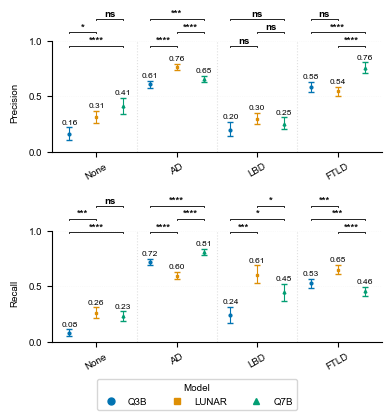

In [34]:
# Create the plot with p-value annotations
plot_classwise_with_pvalues(
    all_metrics=all_metrics,
    pairwise_pvalues=pairwise_comparisons,
    model_map=model_map,
    class_map=class_map,
    show_all_comparisons=True,  # Only show comparisons with baseline (Q3B)
    p_threshold=1,  # Only show significant results
    # figname="np_one"
    fontsize=7,
    # figsize=(3, 2.3),
    # metrics=["f1"],
    # filename="../figures/fig3_np_one_f1.pdf"
    figsize=(4, 4),
    filename="../figures/fig3_np_one_prec_rec.pdf"
)